## multiple traj.  position

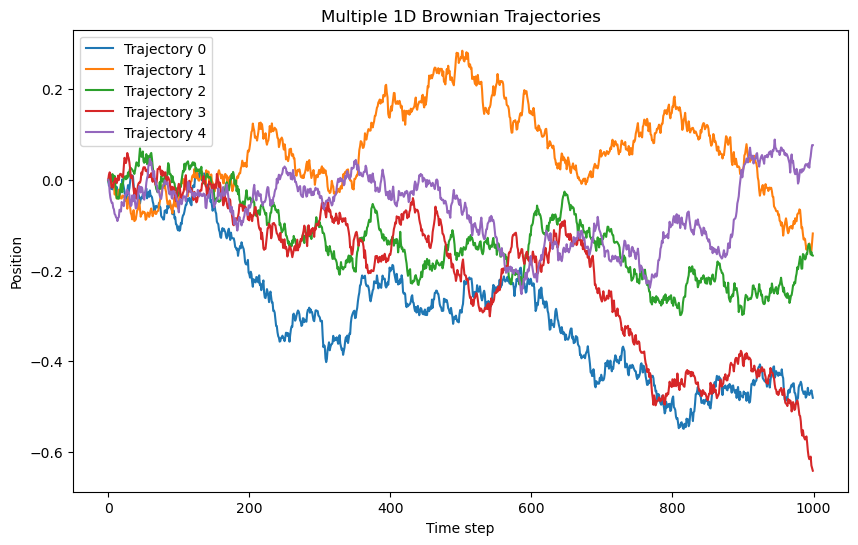

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_multiple_langevin(n_traj, n_steps, dt, D):

    # Create 2D array: rows = trajectories, columns = time
    x = np.zeros((n_traj, n_steps))

    scale_factor = np.sqrt(2 * D * dt)

    # Generate all random kicks at once
    random_kicks = np.random.normal(0.0, 1.0, size=(n_traj, n_steps))

    # Update positions
    for traj in range(n_traj):
        for i in range(1, n_steps):
            dx = scale_factor * random_kicks[traj, i-1]
            x[traj, i] = x[traj, i-1] + dx

    return x



# Parameters


n_traj = 5    # number of trajectories
n_steps = 1000  # time points
dt = 0.0001
D = 0.5


# Generate trajectories
trajectories = generate_multiple_langevin(n_traj, n_steps, dt, D)



# Visualization


plt.figure(figsize=(10,6))

for traj in range(n_traj):
    plt.plot(trajectories[traj], label=f"Trajectory {traj}")

plt.title("Multiple 1D Brownian Trajectories")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.legend()
plt.show()


## TAMSD  for multi tarj.

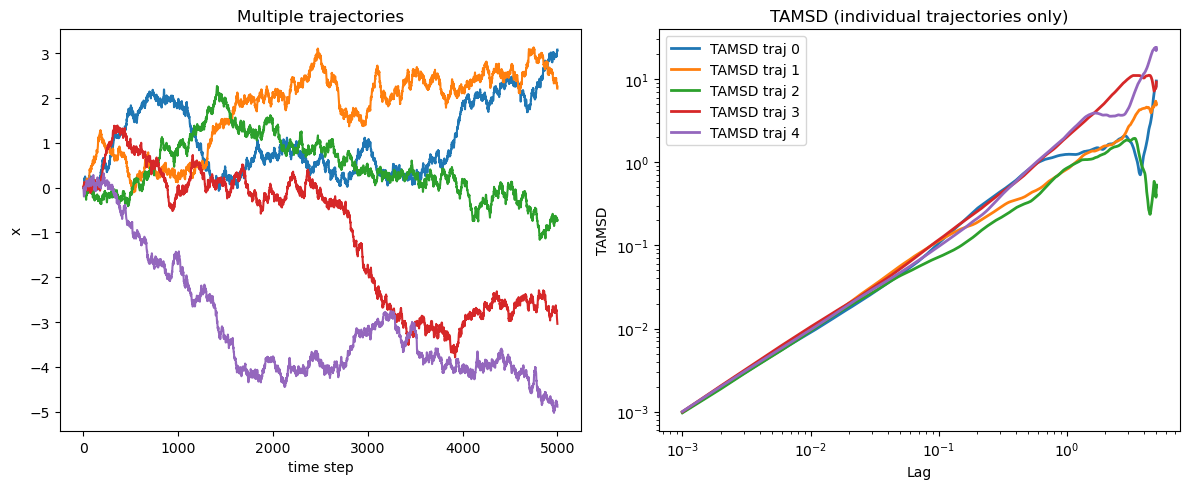

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def generate_multiple_langevin(n_traj, n_steps, dt, D):

    x = np.zeros((n_traj, n_steps))

    scale_factor = np.sqrt(2 * D * dt)

    random_kicks = np.random.normal(0.0, 1.0, size=(n_traj, n_steps))

    for traj in range(n_traj):
        for i in range(1, n_steps):
            x[traj, i] = x[traj, i-1] + scale_factor * random_kicks[traj, i-1]

    return x



def calculate_tamsd_multiple(trajectories, dt):

    n_traj, N = trajectories.shape

    max_lag = N-1

    lags = np.arange(1, max_lag + 1) * dt

    tamsd_all = np.zeros((n_traj, max_lag))


    for traj in range(n_traj):

        x = trajectories[traj]

        for n in range(1, max_lag + 1):

            dx = x[n:] - x[:-n]

            tamsd_all[traj, n-1] = np.mean(dx**2)


    return lags, tamsd_all




# Parameters
n_traj = 5
n_steps = 5000
dt = 0.001
D = 0.5


# Generate trajectories
trajectories = generate_multiple_langevin(n_traj, n_steps, dt, D)


# Calculate TAMSD
lags, tamsd_all = calculate_tamsd_multiple(trajectories, dt)



# Plot trajectories
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

for traj in range(n_traj):
    plt.plot(trajectories[traj])

plt.title("Multiple trajectories")
plt.xlabel("time step")
plt.ylabel("x")



# Plot TAMSD (ONLY individual TAMSD)
plt.subplot(1,2,2)

for traj in range(n_traj):

    plt.loglog(lags, tamsd_all[traj],
               linewidth=2,
               label=f"TAMSD traj {traj}")



plt.title("TAMSD (individual trajectories only)")

plt.xlabel("Lag")

plt.ylabel("TAMSD")

plt.legend()

plt.tight_layout()

plt.show()


## IN log scale

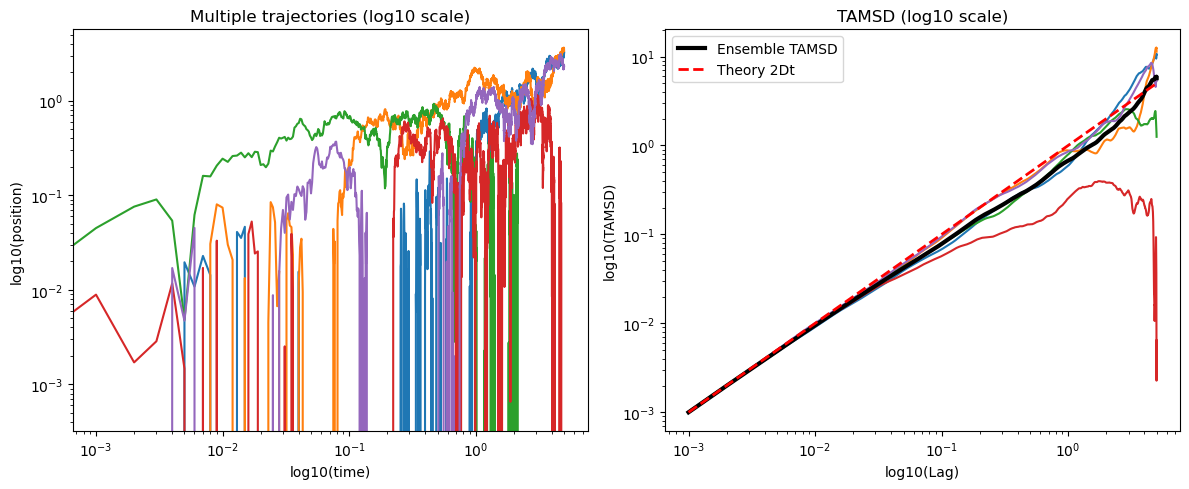

In [33]:
import numpy as np
import matplotlib.pyplot as plt


def generate_multiple_langevin(n_traj, n_steps, dt, D):

    x = np.zeros((n_traj, n_steps))

    scale_factor = np.sqrt(2 * D * dt)

    random_kicks = np.random.normal(0.0, 1.0, size=(n_traj, n_steps))

    for traj in range(n_traj):
        for i in range(1, n_steps):
            x[traj, i] = x[traj, i-1] + scale_factor * random_kicks[traj, i-1]

    return x


def calculate_tamsd_multiple(trajectories, dt):

    n_traj, N = trajectories.shape

    max_lag = N-1

    lags = np.arange(1, max_lag + 1) * dt

    tamsd_all = np.zeros((n_traj, max_lag))

    for traj in range(n_traj):

        x = trajectories[traj]

        for n in range(1, max_lag + 1):

            dx = x[n:] - x[:-n]

            tamsd_all[traj, n-1] = np.mean(dx**2)


    tamsd_mean = np.mean(tamsd_all, axis=0)

    return lags, tamsd_all, tamsd_mean



# Parameters
n_traj = 5
n_steps = 5000
dt = 0.001
D = 0.5


# Generate trajectories
trajectories = generate_multiple_langevin(n_traj, n_steps, dt, D)

lags, tamsd_all, tamsd_mean = calculate_tamsd_multiple(trajectories, dt)


# Time axis
time = np.arange(n_steps) * dt


plt.figure(figsize=(12,5))


# ------------------------------------------------
# Trajectories (LOG10 scale)
# ------------------------------------------------

plt.subplot(1,2,1)

for traj in range(n_traj):
    plt.plot(time, trajectories[traj])

plt.xscale("log")
plt.yscale("log")

plt.title("Multiple trajectories (log10 scale)")
plt.xlabel("log10(time)")
plt.ylabel("log10(position)")


# ------------------------------------------------
# TAMSD plot (LOG10 scale)
# ------------------------------------------------

plt.subplot(1,2,2)

for traj in range(n_traj):
    plt.plot(lags, tamsd_all[traj])

plt.plot(lags, tamsd_mean, 'k', linewidth=3, label="Ensemble TAMSD")

plt.plot(lags, 2*D*lags, 'r--', linewidth=2, label="Theory 2Dt")


plt.xscale("log")
plt.yscale("log")

plt.title("TAMSD (log10 scale)")
plt.xlabel("log10(Lag)")
plt.ylabel("log10(TAMSD)")

plt.legend()

plt.tight_layout()

plt.show()


Slope = 0.9665461761303235
Diffusion coefficient = 0.5822280696044683
RMSE = 0.04469314754657746


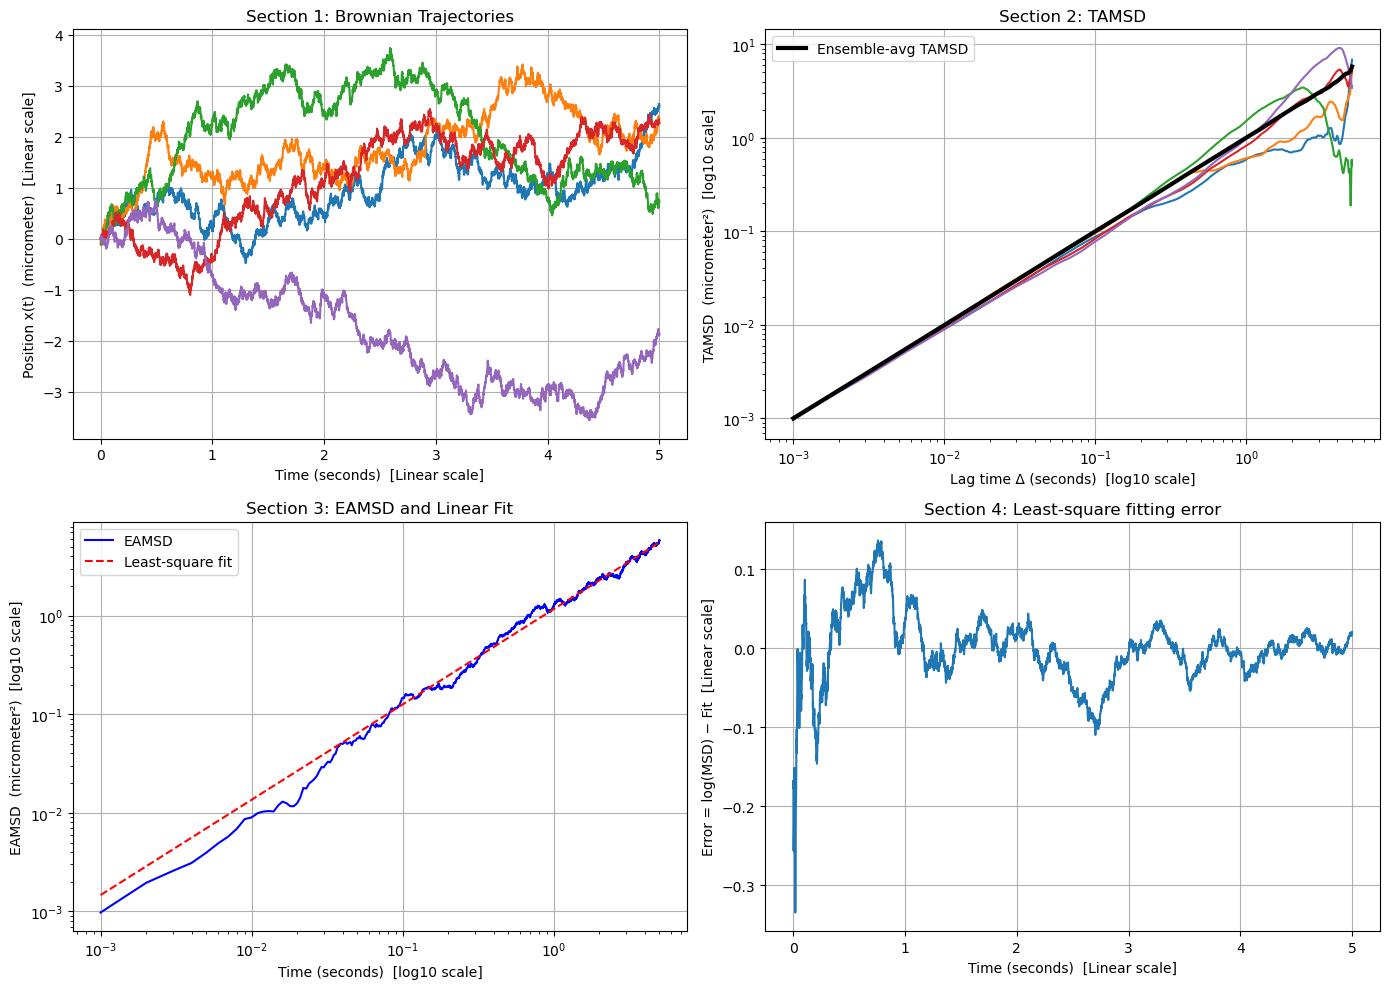

In [36]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Generate trajectories
# -----------------------------

def generate_multiple_langevin(n_traj,n_steps,dt,D):

    x=np.zeros((n_traj,n_steps))

    scale=np.sqrt(2*D*dt)

    noise=np.random.normal(0,1,(n_traj,n_steps))

    for traj in range(n_traj):

        for i in range(1,n_steps):

            x[traj,i]=x[traj,i-1]+scale*noise[traj,i-1]

    return x


# -----------------------------
# TAMSD
# -----------------------------

def calculate_tamsd(trajectories,dt):

    n_traj,N=trajectories.shape

    max_lag=N-1

    lags=np.arange(1,max_lag+1)*dt

    tamsd_all=np.zeros((n_traj,max_lag))

    for traj in range(n_traj):

        x=trajectories[traj]

        for n in range(1,max_lag+1):

            dx=x[n:]-x[:-n]

            tamsd_all[traj,n-1]=np.mean(dx**2)

    tamsd_mean=np.mean(tamsd_all,axis=0)

    return lags,tamsd_all,tamsd_mean


# -----------------------------
# EAMSD
# -----------------------------

def calculate_eamsd(trajectories):

    eamsd=np.mean((trajectories-trajectories[:,0][:,None])**2,axis=0)

    return eamsd


# -----------------------------
# Least square fitting
# -----------------------------

def least_square(time,msd):

    x=np.log10(time)

    y=np.log10(msd)

    m,c=np.polyfit(x,y,1)

    y_fit=m*x+c

    error=y-y_fit

    rmse=np.sqrt(np.mean(error**2))

    return m,c,y_fit,error,rmse



# PARAMETERS

n_traj=50

n_steps=5000

dt=0.001

D=0.5


# SIMULATION

trajectories=generate_multiple_langevin(n_traj,n_steps,dt,D)

lags,tamsd_all,tamsd_mean=calculate_tamsd(trajectories,dt)

time=np.arange(n_steps)*dt

eamsd=calculate_eamsd(trajectories)


# FITTING

m,c,y_fit,error,rmse=least_square(time[1:],eamsd[1:])


print("Slope =",m)

print("Diffusion coefficient =",10**c/2)

print("RMSE =",rmse)



# -----------------------------
# PLOTS
# -----------------------------

plt.figure(figsize=(14,10))


# -----------------------------------------
# SECTION 1 : TRAJECTORIES
# -----------------------------------------

plt.subplot(2,2,1)

for traj in range(5):

    plt.plot(time,trajectories[traj])

plt.xlabel("Time (seconds)  [Linear scale]")

plt.ylabel("Position x(t)  (micrometer)  [Linear scale]")

plt.title("Section 1: Brownian Trajectories")

plt.grid(True)



# -----------------------------------------
# SECTION 2 : TAMSD
# -----------------------------------------

plt.subplot(2,2,2)

for traj in range(5):

    plt.loglog(lags,tamsd_all[traj])

plt.loglog(lags,tamsd_mean,'k',linewidth=3,label="Ensemble-avg TAMSD")

plt.xlabel("Lag time Δ (seconds)  [log10 scale]")

plt.ylabel("TAMSD  (micrometer²)  [log10 scale]")

plt.title("Section 2: TAMSD")

plt.legend()

plt.grid(True)



# -----------------------------------------
# SECTION 3 : EAMSD + FIT
# -----------------------------------------

plt.subplot(2,2,3)

plt.loglog(time[1:],eamsd[1:],'b',label="EAMSD")

plt.loglog(time[1:],10**y_fit,'r--',label="Least-square fit")

plt.xlabel("Time (seconds)  [log10 scale]")

plt.ylabel("EAMSD  (micrometer²)  [log10 scale]")

plt.title("Section 3: EAMSD and Linear Fit")

plt.legend()

plt.grid(True)



# -----------------------------------------
# SECTION 4 : FITTING ERROR
# -----------------------------------------

plt.subplot(2,2,4)

plt.plot(time[1:],error)

plt.xlabel("Time (seconds)  [Linear scale]")

plt.ylabel("Error = log(MSD) − Fit  [Linear scale]")

plt.title("Section 4: Least-square fitting error")

plt.grid(True)



plt.tight_layout()

plt.show()


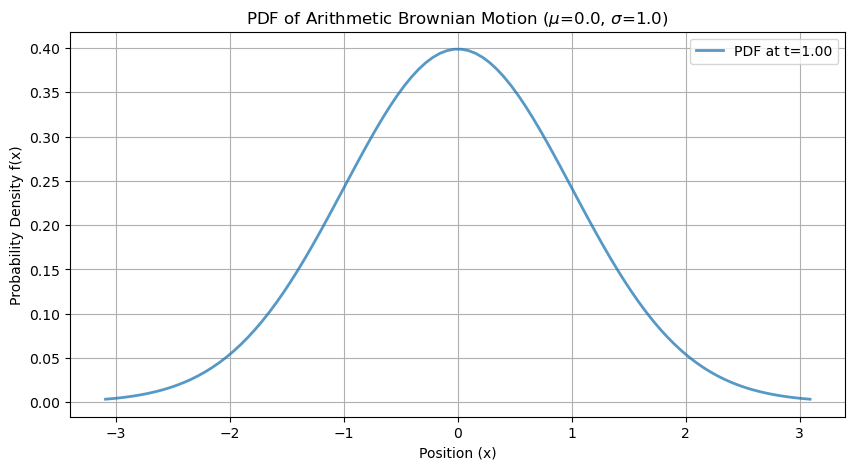

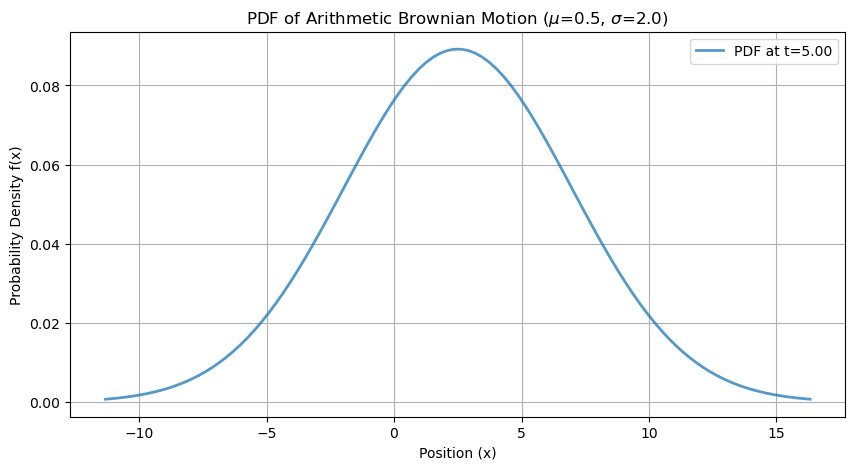

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_brownian_motion_pdf(mu, sigma, t):
    """
    Calculates and plots the PDF of an arithmetic Brownian motion at a given time t.

    Args:
        mu (float): The drift parameter.
        sigma (float): The scale (volatility) parameter.
        t (float): The time at which to calculate the PDF.
    """
    # Define the marginal distribution at time t
    # Mean = mu * t, Standard Deviation = sigma * sqrt(t)
    mean = mu * t
    std_dev = sigma * np.sqrt(t)
    
    # Create a normal distribution object
    distribution = norm(loc=mean, scale=std_dev)
    
    # Generate x values for the plot (range covers most of the probability)
    x = np.linspace(distribution.ppf(0.001), distribution.ppf(0.999), 100)
    
    # Calculate the PDF values
    pdf_values = distribution.pdf(x)
    
    # Plot the PDF
    plt.figure(figsize=(10, 5))
    plt.plot(x, pdf_values, '-', lw=2, alpha=0.75, label=f'PDF at t={t:.2f}')
    plt.title(f'PDF of Arithmetic Brownian Motion ($\mu$={mu}, $\sigma$={sigma})')
    plt.xlabel('Position (x)')
    plt.ylabel('Probability Density f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage for a standard Brownian motion (mu=0, sigma=1) at t=1
plot_brownian_motion_pdf(mu=0.0, sigma=1.0, t=1.0)

# Example usage for a process with drift and different volatility
plot_brownian_motion_pdf(mu=0.5, sigma=2.0, t=5.0)


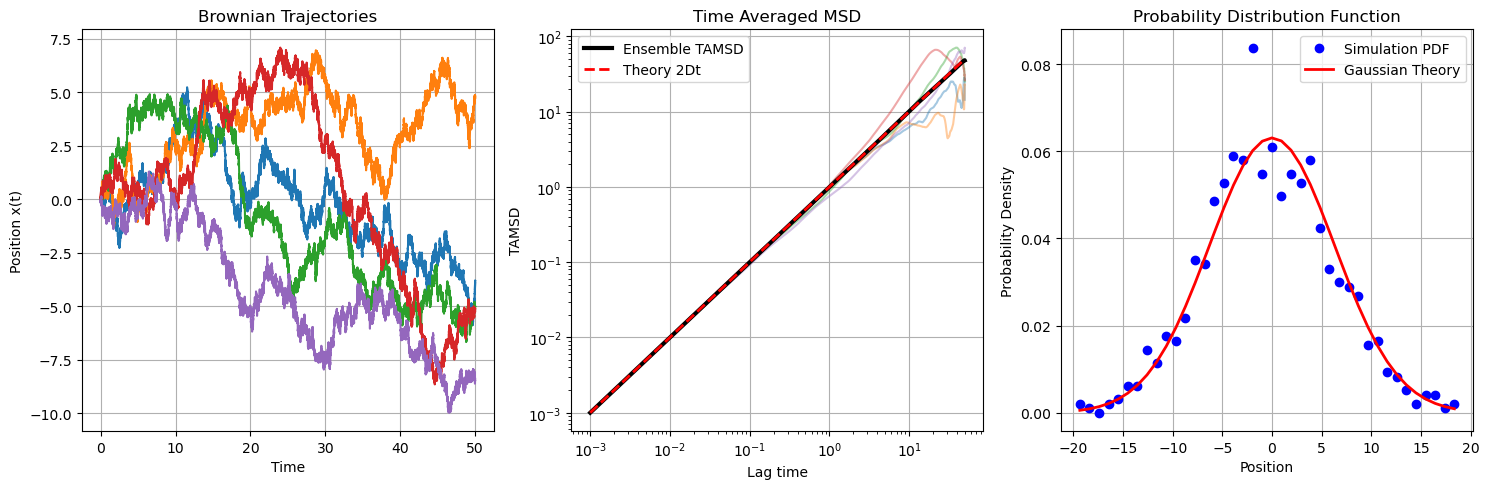

In [37]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Generate Brownian trajectories (Langevin equation)
# ------------------------------------------------

def generate_multiple_langevin(n_traj, n_steps, dt, D):

    x = np.zeros((n_traj, n_steps))

    scale_factor = np.sqrt(2 * D * dt)

    random_kicks = np.random.normal(0.0, 1.0, size=(n_traj, n_steps))

    for traj in range(n_traj):
        for i in range(1, n_steps):

            dx = scale_factor * random_kicks[traj, i-1]

            x[traj, i] = x[traj, i-1] + dx

    return x


# ------------------------------------------------
# TAMSD calculation
# ------------------------------------------------

def calculate_tamsd_multiple(trajectories, dt):

    n_traj, N = trajectories.shape

    max_lag = N-1

    lags = np.arange(1, max_lag + 1) * dt

    tamsd_all = np.zeros((n_traj, max_lag))

    for traj in range(n_traj):

        x = trajectories[traj]

        for n in range(1, max_lag + 1):

            dx = x[n:] - x[:-n]

            tamsd_all[traj, n-1] = np.mean(dx**2)

    tamsd_mean = np.mean(tamsd_all, axis=0)

    return lags, tamsd_all, tamsd_mean


# ------------------------------------------------
# PARAMETERS
# ------------------------------------------------

n_traj = 1000
n_steps = 50000
dt = 0.001
D = 0.5


# ------------------------------------------------
# SIMULATION
# ------------------------------------------------

trajectories = generate_multiple_langevin(n_traj, n_steps, dt, D)

lags, tamsd_all, tamsd_mean = calculate_tamsd_multiple(trajectories, dt)

time = np.arange(n_steps) * dt


# ------------------------------------------------
# PDF calculation
# ------------------------------------------------

t_index = int(0.8 * n_steps)

positions = trajectories[:, t_index]

hist, bins = np.histogram(positions, bins=40, density=True)

bin_centers = (bins[:-1] + bins[1:]) / 2

t_value = time[t_index]

theory_pdf = (1 / np.sqrt(4 * np.pi * D * t_value)) * np.exp(-(bin_centers**2) / (4 * D * t_value))


# ------------------------------------------------
# PLOTS
# ------------------------------------------------

plt.figure(figsize=(15,5))


# -----------------------------------------------
# Trajectories
# -----------------------------------------------

plt.subplot(1,3,1)

for traj in range(5):

    plt.plot(time, trajectories[traj])

plt.xlabel("Time")

plt.ylabel("Position x(t)")

plt.title("Brownian Trajectories")

plt.grid(True)



# -----------------------------------------------
# Ensemble TAMSD
# -----------------------------------------------

plt.subplot(1,3,2)

for traj in range(5):

    plt.loglog(lags, tamsd_all[traj], alpha=0.4)

plt.loglog(lags, tamsd_mean, 'k', linewidth=3, label="Ensemble TAMSD")

plt.loglog(lags, 2*D*lags, 'r--', linewidth=2, label="Theory 2Dt")

plt.xlabel("Lag time")

plt.ylabel("TAMSD")

plt.title("Time Averaged MSD")

plt.legend()

plt.grid(True)



# -----------------------------------------------
# Probability Distribution Function
# -----------------------------------------------

plt.subplot(1,3,3)

plt.plot(bin_centers, hist, 'bo', label="Simulation PDF")

plt.plot(bin_centers, theory_pdf, 'r-', linewidth=2, label="Gaussian Theory")

plt.xlabel("Position")

plt.ylabel("Probability Density")

plt.title("Probability Distribution Function")

plt.legend()

plt.grid(True)


plt.tight_layout()

plt.show()